# 08 · PJM Energy Demand — Machine-Learning Forecasting (LightGBM, multi-horizon)

## Part 8 — Machine-Learning Forecasting

Part 7's classical models used the calendar and the recent remainder. A gradient-boosted tree can use
**everything at once** — lag features (exploiting the persistence from Part 2), rolling means, calendar
flags, and annual Fourier terms — and learn their nonlinear interactions. We frame it as the real
operational task: the **24-hour-ahead** forecast, and then trace accuracy across horizons.

**Leakage discipline.** For an *h*-hour-ahead forecast, every feature must be knowable *h* hours early,
so we use only lags ≥ *h*. `forecasting.ml_features` enforces this.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import forecasting as F
from lightgbm import LGBMRegressor
d = data.clean_primary(); s = d.load_mw
LG = dict(n_estimators=600, learning_rate=0.05, num_leaves=64, random_state=0, verbose=-1, n_jobs=-1)
def fit_eval(h, split="2018-01-01"):
    X = F.ml_features(s, d, h); m = X.dropna().index
    tr = m < split
    Xtr, ytr = X.loc[m][tr], s.loc[m][tr]; Xte, yte = X.loc[m][~tr], s.loc[m][~tr]
    yp = LGBMRegressor(**LG).fit(Xtr, ytr).predict(Xte)
    return yte, pd.Series(yp, index=yte.index), Xtr.columns
print("test period = 2018 (train: everything before)")

setup ok | numpy 2.1.3 | pandas 2.3.3


test period = 2018 (train: everything before)


### 1. The 24-hour-ahead model

Train on 2002–2017, forecast every hour of 2018 one day ahead. LightGBM reaches **~6.3% MAPE
(MASE 0.94)** — beating both the seasonal-naive baseline (7.9%) *and* the classical MSTL winner from
Part 7 (~7.2%) — by blending persistence, calendar and nonlinearity in a single model.

MAE      2029.588
RMSE     2725.405
MAPE%       6.271
WAPE%       6.386
MASE        0.940

vs seasonal-naive-24h MAPE: 7.90%


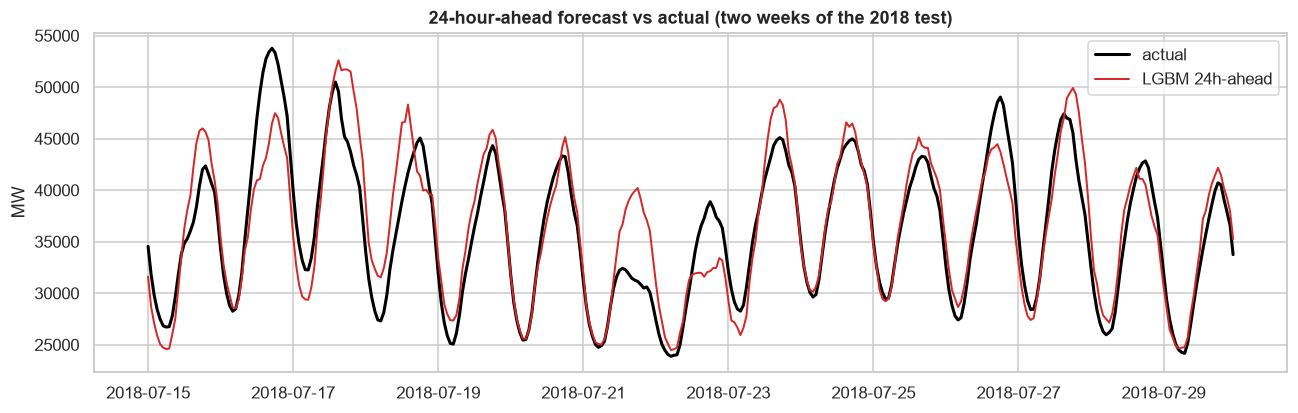

In [2]:
yte, yp, feats = fit_eval(24)
train_s = s.loc[:yte.index[0]].iloc[:-1]                 # in-sample series for the MASE scale
print(F.metrics(yte.values, yp.values, train_s, "LGBM-24h").to_string())
print("\nvs seasonal-naive-24h MAPE: %.2f%%" % (np.mean(np.abs((yte.values - s.shift(24).loc[yte.index].values)/yte.values))*100))
win = slice("2018-07-15", "2018-07-29")
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(yte.loc[win].index, yte.loc[win].values, color="black", lw=2, label="actual")
ax.plot(yp.loc[win].index, yp.loc[win].values, color="tab:red", lw=1.3, label="LGBM 24h-ahead")
ax.set_ylabel("MW"); ax.set_title("24-hour-ahead forecast vs actual (two weeks of the 2018 test)"); ax.legend()
eda.savefig(fig, "p8_forecast.png"); plt.show()

### 2. What the model uses — feature importance

The **rolling-mean lags** (`roll168` weekly, `roll24` daily) dominate — the model is mostly riding the
**persistence** Part 2 quantified — with **day-of-week** and the **annual Fourier** terms supplying the
calendar context. Raw single lags matter less once the smooth rolling means are present.

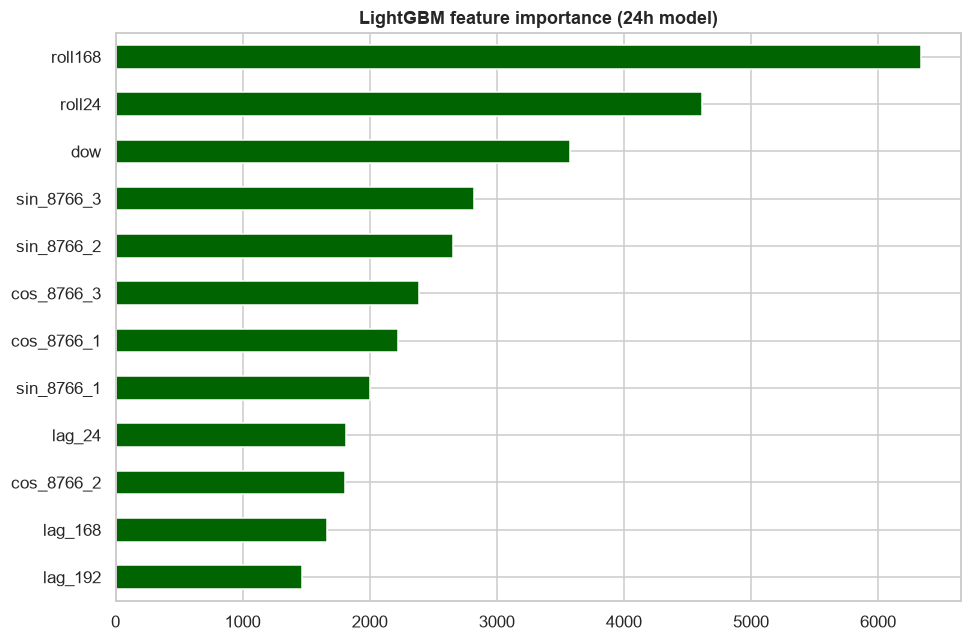

top: ['roll168', 'roll24', 'dow', 'sin_8766_3']


In [3]:
mdl = LGBMRegressor(**LG)
X = F.ml_features(s, d, 24); m = X.dropna().index; tr = m < "2018-01-01"
mdl.fit(X.loc[m][tr], s.loc[m][tr])
imp = pd.Series(mdl.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 6)); imp.tail(12).plot.barh(ax=ax, color="darkgreen")
ax.set_title("LightGBM feature importance (24h model)"); fig.tight_layout()
eda.savefig(fig, "p8_importance.png"); plt.show()
print("top:", list(imp.tail(4).index[::-1]))

### 3. How far ahead can we see? — accuracy vs horizon

Retraining for horizons of 1, 6, 24, 72 and 168 hours shows error **growing smoothly with horizon** as
the freshest usable lag gets staler: **0.7% at 1h, ~6% day-ahead, ~9% week-ahead**. The curve is the
honest answer to "how predictable is demand?" — extremely so short-term, still useful a week out.

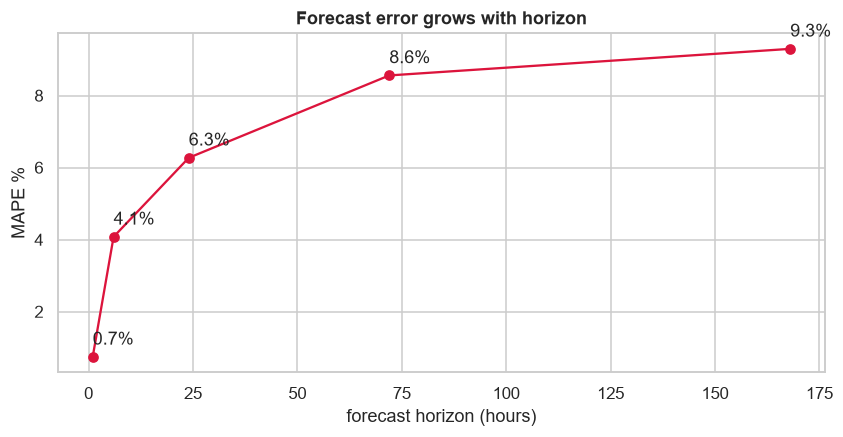

           MAE  MAPE%   MASE
1h     239.144  0.743  0.111
6h    1313.620  4.076  0.608
24h   2029.588  6.271  0.940
72h   2758.422  8.558  1.277
168h  3008.132  9.296  1.393


In [4]:
rows = []
for h in [1, 6, 24, 72, 168]:
    yt, yp_h, _ = fit_eval(h)
    rows.append(F.metrics(yt.values, yp_h.values, s.loc[:yt.index[0]], f"{h}h").rename(f"{h}h"))
hz = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot([1,6,24,72,168], hz["MAPE%"], "o-", color="crimson")
ax.set_xlabel("forecast horizon (hours)"); ax.set_ylabel("MAPE %"); ax.set_title("Forecast error grows with horizon")
for h, v in zip([1,6,24,72,168], hz["MAPE%"]): ax.annotate(f"{v:.1f}%", (h, v), textcoords="offset points", xytext=(0,8))
eda.savefig(fig, "p8_horizon.png"); plt.show()
print(hz[["MAE","MAPE%","MASE"]].to_string())

### Takeaways

- A **LightGBM** with lag + rolling + calendar + Fourier features forecasts **day-ahead at ~6.3% MAPE
  (MASE 0.94)** — beating both the seasonal-naive baseline and the classical MSTL model.
- **Rolling-mean lags dominate** importance — the model rides the series' strong persistence, with
  day-of-week and annual terms for calendar context.
- **Accuracy degrades smoothly with horizon** (0.7% → 6% → 9% from 1h to a week) — load is extremely
  predictable short-term and still useful a week out.
- All strictly **leakage-safe** (lags ≥ horizon).

**Next — Part 9 (Probabilistic forecasting & backtesting):** a point forecast isn't enough for grid
planning — we add **prediction intervals** (conformal), a **walk-forward backtest**, and a look at how
well we forecast the **peak** specifically.